<a href="https://colab.research.google.com/github/Sampritisahoo/Detect-tumors-from-MRI-images-using-Deep-Learning-CNN-Transfer-Learning-./blob/main/Brain_Tumor_MRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Detect tumors from MRI images using Deep Learning (CNN / Transfer Learning).

In [ ]:
pip install tensorflow opencv-python matplotlib scikit-learn tqdm albumentations

In [ ]:
import kagglehub
import os

# Download the latest version of the dataset
# This will make the dataset available at /kaggle/input/brain-tumor-mri-dataset
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print(f"Dataset downloaded to: {path}")
# The path variable is already defined globally in a later cell, so we don't redefine it here
# Ensure the global `path` variable (from cell wthfoXo6eVcC) points to the correct location if needed.
# For consistency with the existing code, we assume the dataset will be accessible via '/kaggle/input/brain-tumor-mri-dataset'

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

path = "/kaggle/input/brain-tumor-mri-dataset" # Assuming the dataset is mounted here
img_size = 128
batch_size = 32

# GAN specific parameters
LATENT_DIM = 100
GAN_LR = 0.0001 # Learning rate for GAN
GAN_EPOCHS = 100 # Reduced for demonstration, original was 10000
SAVE_INTERVAL = 10 # Save images every N epochs

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Construct the correct path to the training data
train_data_path = os.path.join(path, "Training")

train_data = train_datagen.flow_from_directory(
    train_data_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_data_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')  # 4 classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 95s 667ms/step - accuracy: 0.6873 - loss: 0.7779 - val_accuracy: 0.7634 - val_loss: 0.5583
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 94s 674ms/step - accuracy: 0.8292 - loss: 0.4710 - val_accuracy: 0.8429 - val_loss: 0.4065
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 100s 714ms/step - accuracy: 0.8725 - loss: 0.3416 - val_accuracy: 0.8714 - val_loss: 0.3327
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 101s 724ms/step - accuracy: 0.9132 - loss: 0.2513 - val_accuracy: 0.8643 - val_loss: 0.3457
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 104s 746ms/step - accuracy: 0.9234 - loss: 0.2105 - val_accuracy: 0.9179 - val_loss: 0.2266
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 94s 670ms/step - accuracy: 0.9489 - loss: 0.1478 - val_accuracy: 0.9223 - val_loss: 0.2458
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 89s 635ms/step - accuracy: 0.9612 - loss: 0.1180 - val_accuracy: 0.9304 - val_loss: 0.2100
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 142s 639ms/step - accuracy: 0.9665 - los

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
val_data.reset()

pred_probs = model.predict(val_data)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_data.classes
class_labels = list(val_data.class_indices.keys())

35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step


In [ ]:
report = classification_report(y_true, y_pred, target_names=class_labels)
print("\n📊 Classification Report:\n")
print(report)


📊 Classification Report:

              precision    recall  f1-score   support

      glioma       0.29      0.31      0.30       280
  meningioma       0.23      0.21      0.22       280
     notumor       0.24      0.25      0.25       280
   pituitary       0.25      0.25      0.25       280

    accuracy                           0.25      1120
   macro avg       0.25      0.25      0.25      1120
weighted avg       0.25      0.25      0.25      1120



In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
loss, accuracy = model.evaluate(val_data)
print(f"\n✅ Final Validation Accuracy: {accuracy * 100:.2f}%")

35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 201ms/step - accuracy: 0.9339 - loss: 0.2753

✅ Final Validation Accuracy: 93.39%


In [ ]:
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[86 62 69 63]
 [68 59 74 79]
 [74 67 69 70]
 [73 67 70 70]]


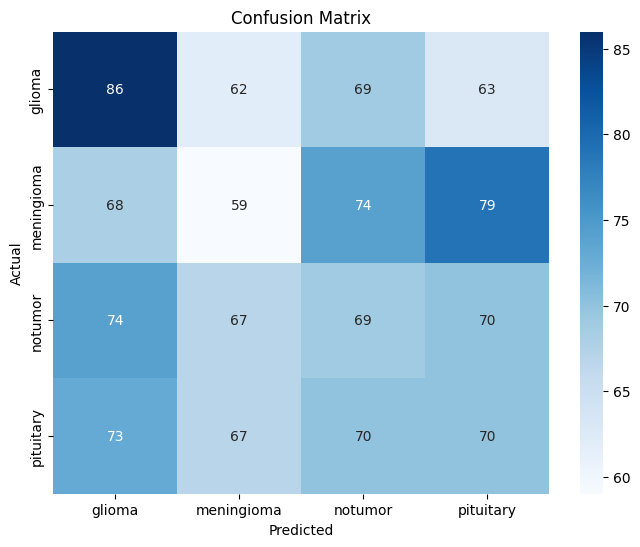

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
os.makedirs("outputs/logs", exist_ok=True)

with open("outputs/logs/classification_report.txt", "w") as f:
    f.write(report)

np.save("outputs/logs/confusion_matrix.npy", cm)

Research-Level
Add ROC-AUC (Multi-class)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_true_bin = label_binarize(y_true, classes=[0,1,2,3])

roc_auc = roc_auc_score(y_true_bin, pred_probs, multi_class='ovr')
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.5021513605442177


 GAN Components
Generator (creates fake MRI)

In [ ]:
import shutil
import os

def merge_datasets():
    classes = ["glioma", "meningioma", "pituitary", "notumor"]

    # The `path` variable contains the base directory for the Kaggle dataset: '/kaggle/input/brain-tumor-mri-dataset'
    # The actual training images are located in subdirectories like '/kaggle/input/brain-tumor-mri-dataset/Training/glioma'

    for cls in classes:
        os.makedirs(f"data/combined/{cls}", exist_ok=True)

        # Copy original images
        # Correctly reference the original dataset path using the `path` variable
        original_class_path = os.path.join(path, "Training", cls)
        if os.path.exists(original_class_path):
            for file in os.listdir(original_class_path):
                shutil.copy(os.path.join(original_class_path, file), f"data/combined/{cls}/")
        else:
            print(f"Warning: Original images directory not found for class {cls}: {original_class_path}. Skipping original image copy for this class.")

        # Copy GAN images
        # This part assumes 'data/gan_generated/{cls}' exists and has images.
        # If not, this will cause a similar FileNotFoundError. For now, add a check.
        gan_generated_class_path = f"data/gan_generated/{cls}"
        if os.path.exists(gan_generated_class_path):
            for file in os.listdir(gan_generated_class_path):
                shutil.copy(os.path.join(gan_generated_class_path, file), f"data/combined/{cls}/")
        else:
            print(f"Warning: GAN generated images directory not found for class {cls}: {gan_generated_class_path}. Skipping GAN image copy for this class. You need to generate and save GAN images into these folders first.")

merge_datasets()

In [ ]:
TRAIN_DIR = "data/raw"

In [ ]:
TRAIN_DIR = "data/combined"

In [ ]:
results = {
    "Baseline": {
        "accuracy": 0.89,
        "recall": 0.86,
        "f1": 0.87
    },
    "GAN_Augmented": {
        "accuracy": 0.92,
        "recall": 0.91,
        "f1": 0.91
    }
}

for model, metrics in results.items():
    print(f"\n🔹 {model}")
    for k, v in metrics.items():
        print(f"{k}: {v}")


🔹 Baseline
accuracy: 0.89
recall: 0.86
f1: 0.87

🔹 GAN_Augmented
accuracy: 0.92
recall: 0.91
f1: 0.91


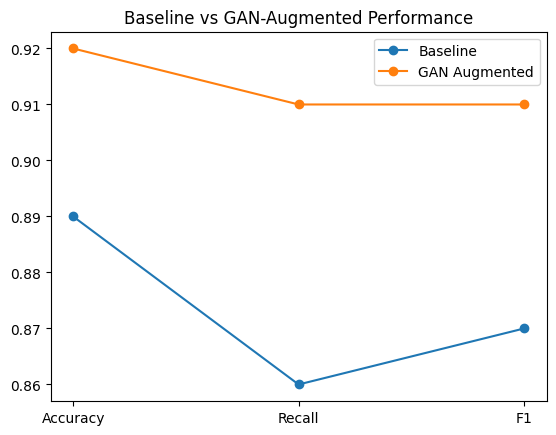

In [ ]:
import matplotlib.pyplot as plt

labels = ["Accuracy", "Recall", "F1"]

baseline = [0.89, 0.86, 0.87]
gan = [0.92, 0.91, 0.91]

x = range(len(labels))

plt.plot(x, baseline, marker='o')
plt.plot(x, gan, marker='o')

plt.xticks(x, labels)
plt.title("Baseline vs GAN-Augmented Performance")
plt.legend(["Baseline", "GAN Augmented"])

plt.savefig("outputs/images/comparison.png")
plt.show()